**Import Libraries**

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torch.utils.data import TensorDataset
from torch.utils.data import Dataset
from torch.nn.utils.rnn import pad_sequence
import matplotlib.pyplot as plt
from tqdm.auto import trange
import os
import random
from LCNN_backend import LCNN
from sklearn.model_selection import train_test_split


d:\anaconda\envs\deepfake\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


**Parameters for data preprocessing**

In [2]:
# Number of file to pick in both training and development set
# num_files_to_pick = 10000    
# 
DATASET_MAP = {
    'asv2019': {
        'train': 'C:\\Users\\Zheng\\Desktop\\project\\team_lab_deepfake\\lfcc_tensors_train_set_with_delta\\lfcc_tensors_train_set_with_delta',
        'dev': 'C:\\Users\\Zheng\\Desktop\\project\\team_lab_deepfake\\lfcc_tensors_dev_set_with_delta\\lfcc_tensors_dev_set_with_delta',
        'eval': 'C:\\Users\\Zheng\\Desktop\\project\\team_lab_deepfake\\lfcc_tensors_eval_set_with_delta\\lfcc_tensors_eval_set_with_delta'
    },
    'add2022': {
        'train': 'C:\\Users\\Zheng\\Desktop\\project\\team_lab_deepfake\\add_lfcc_with_delta_train',
        'dev':   'C:\\Users\\Zheng\\Desktop\\project\\team_lab_deepfake\\add_lfcc_with_delta_dev',
        'eval': 'C:\\Users\\Zheng\\Desktop\\project\\team_lab_deepfake\\add_lfcc_with_delta_eval',
    },
    'itw': {
        'train': 'C:\\Users\\Zheng\\Desktop\\project\\team_lab_deepfake\\itw_lfcc_with_delta',
    }
}                                                  

CURRENT_DATA = 'itw'
if CURRENT_DATA != 'itw':
    train_path = DATASET_MAP[CURRENT_DATA]['train']
    dev_path = DATASET_MAP[CURRENT_DATA]['dev']
else:
    train_path = DATASET_MAP[CURRENT_DATA]['train']


**Preprocessing of training data** 

In [3]:
# Set the number of files to pick and the random seed
random_seed = 42

# List all .pt files in the directory
all_files = [f for f in os.listdir(train_path) if f.endswith('.pt')]

# Set the random seed for reproducibility
#random.seed(random_seed)

# Randomly select the specified number of files
# selected_files = random.sample(all_files, num_files_to_pick)
if CURRENT_DATA == 'itw':
    train_files, dev_files = train_test_split(all_files, test_size=0.4, random_state=random_seed)
    dev_files, eval_files = train_test_split(dev_files, test_size=0.5, random_state=random_seed)
# Inspect a single .pt file before loading into classes
else:
    train_files = all_files

inspect_file = os.path.join(train_path, train_files[0])  # Select the first file from the random selection

# Inspect the data from the .pt file
inspect_data = torch.load(inspect_file)
print("Example of the .pt file",inspect_data[0])

# Initialize a list to store the features and labels
features_list = []
labels_list = []

# Load the features and labels for the selected .pt files
for file_name in train_files:
    file_path = os.path.join(train_path, file_name)
    feature, label = torch.load(file_path)
    features_list.append(feature)  # Append the tensors
    labels_list.append(label) # Append the labels

# Concatenate all the data into a single tensor
features = torch.stack(features_list)
print("Example of the features",features[1])
labels = torch.tensor(labels_list)
print("Example of the labels",labels)

# Debugging: Check the shapes of features and labels
print("Features shape:", features.shape)
print("Labels shape:", labels.shape)

# Create a TensorDataset and DataLoader
dataset = TensorDataset(features, labels)
dataLoader = DataLoader(dataset, batch_size=64, shuffle=True)
print("The training dataset has been successfully loaded into DataLoader.")

Example of the .pt file tensor([[ 4.3987e+01,  3.4148e+01,  2.0774e+01,  ...,  3.5123e+01,
          1.5437e+01,  3.5362e+00],
        [ 7.7094e+01,  7.8591e+01,  8.4222e+01,  ...,  8.7463e+01,
          8.7576e+01,  8.7320e+01],
        [-1.5395e+01, -1.6307e+01, -2.0999e+01,  ..., -2.0298e+01,
         -2.5983e+01, -2.3209e+01],
        ...,
        [ 7.6907e-01,  7.6907e-01,  7.6907e-01,  ..., -2.9194e-02,
         -2.9194e-02, -2.9194e-02],
        [-3.8934e-01, -3.8934e-01, -3.8934e-01,  ...,  3.2401e-01,
          3.2401e-01,  3.2401e-01],
        [ 2.1338e-01,  2.1338e-01,  2.1338e-01,  ...,  2.4211e-01,
          2.4211e-01,  2.4211e-01]])
Example of the features tensor([[-4.3724e+02, -4.4140e+02, -4.5265e+02,  ..., -1.9387e+02,
         -2.3900e+02, -2.1721e+02],
        [ 4.1408e+01,  3.5733e+01,  2.0169e+01,  ...,  1.5738e+02,
          1.6065e+02,  1.5016e+02],
        [ 3.9328e+01,  3.4264e+01,  1.9702e+01,  ...,  2.5277e+01,
          4.3525e+01,  4.2269e+01],
        ...

**Dataset inspection**

In [4]:
# Inspect the range of labels in the dataset
#print("Minimum label value:", labels.min().item())
#print("Maximum label value:", labels.max().item())
#print("Unique label values:", torch.unique(labels))

# Inspect the first sample in the batch
print("First sample shape:", features[0].shape)
print("First sample values:\n", features[0])


# Inspect the concatenated tensor
#print("Data Tensor Shape:", data_tensor.shape)
#print("Data Tensor Data Type:", data_tensor.dtype)
#print("Sample Data Tensor Values:\n", data_tensor[:5])  # Print the first 5 rows

# Inspect features and labels
#print("Features Shape:", features.shape)
#print("Labels Shape:", labels.shape)
#print("Sample Features:\n", features[:5])  # Print the first 5 rows of features
print("Sample Labels:\n", labels[:100])  # Print the first 5 labels

First sample shape: torch.Size([120, 126])
First sample values:
 tensor([[ 4.3987e+01,  3.4148e+01,  2.0774e+01,  ...,  3.5123e+01,
          1.5437e+01,  3.5362e+00],
        [ 7.7094e+01,  7.8591e+01,  8.4222e+01,  ...,  8.7463e+01,
          8.7576e+01,  8.7320e+01],
        [-1.5395e+01, -1.6307e+01, -2.0999e+01,  ..., -2.0298e+01,
         -2.5983e+01, -2.3209e+01],
        ...,
        [ 7.6907e-01,  7.6907e-01,  7.6907e-01,  ..., -2.9194e-02,
         -2.9194e-02, -2.9194e-02],
        [-3.8934e-01, -3.8934e-01, -3.8934e-01,  ...,  3.2401e-01,
          3.2401e-01,  3.2401e-01],
        [ 2.1338e-01,  2.1338e-01,  2.1338e-01,  ...,  2.4211e-01,
          2.4211e-01,  2.4211e-01]])
Sample Labels:
 tensor([0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1,
        1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1,
        0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0,
        0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 

**Testing the Data Loader**

In [5]:
print(len(dataset[0][0]))
print(features.shape)

for batch in dataLoader:
    features, labels = batch
    print("Batch features shape:", features.shape)
    break

120
torch.Size([19067, 120, 126])
Batch features shape: torch.Size([64, 120, 126])


**Preprocessing and loading the Development/Validation Set**

In [6]:
# Set the number of files to pick and the random seed
#random_seed = 42

# Set the random seed for reproducibility
#random.seed(random_seed)
# List all .pt files in the directory
# Randomly select the specified number of files
# selected_files = random.sample(all_files, num_files_to_pick)
if CURRENT_DATA == 'itw':
    target_dev_files = dev_files
    target_dev_path = train_path
else:
    target_dev_files = [f for f in os.listdir(dev_path) if f.endswith('.pt')]
    target_dev_path = dev_path

# Inspect a single .pt file before loading into classes
inspect_file = os.path.join(target_dev_path, target_dev_files[0])  # Select the first file from the random selection

# Inspect the data from the .pt file
inspect_data = torch.load(inspect_file)
print("Example of the .pt file",inspect_data[0])

# Initialize a list to store the features and labels
dev_features_list = []
dev_labels_list = []

# Load the features and labels for the selected .pt files
for file_name in target_dev_files:
    file_path = os.path.join(target_dev_path, file_name)
    dev_feature, dev_label = torch.load(file_path)
    dev_features_list.append(dev_feature)  # Append the tensors
    dev_labels_list.append(dev_label) # Append the labels

# Concatenate all the data into a single tensor
dev_features = torch.stack(dev_features_list)
print("Example of the features",dev_features[1])
dev_labels = torch.tensor(dev_labels_list)
print("Example of the labels",dev_labels)

# Debugging: Check the shapes of features and labels
print("Features shape:", dev_features.shape)
print("Labels shape:", dev_labels.shape)

# Create a TensorDataset and DataLoader
dev_dataset = TensorDataset(dev_features, dev_labels)
dev_dataLoader = DataLoader(dev_dataset, batch_size=64, shuffle=False)
print("The development dataset has been successfully loaded into DataLoader.")

Example of the .pt file tensor([[-4.9611e+02, -4.9611e+02, -4.9611e+02,  ..., -3.0777e+02,
         -1.9656e+02, -1.4818e+02],
        [-6.5226e-07, -6.5226e-07, -6.5226e-07,  ...,  1.8843e+02,
          1.9715e+02,  1.8404e+02],
        [-1.5661e-05, -1.5661e-05, -1.5661e-05,  ...,  6.9171e+01,
          4.5038e+01,  4.8441e+01],
        ...,
        [-2.2520e-01, -2.2520e-01, -2.2520e-01,  ...,  2.8818e-01,
          2.8818e-01,  2.8818e-01],
        [-1.5446e-01, -1.5446e-01, -1.5446e-01,  ..., -1.0367e-02,
         -1.0367e-02, -1.0367e-02],
        [ 2.9782e-02,  2.9782e-02,  2.9782e-02,  ...,  2.2914e-01,
          2.2914e-01,  2.2914e-01]])
Example of the features tensor([[-2.5328e+02, -2.5278e+02, -2.6021e+02,  ..., -1.5814e+02,
         -1.6372e+02, -1.8062e+02],
        [ 9.6442e+01,  9.7869e+01,  1.0343e+02,  ...,  1.6532e+02,
          1.6119e+02,  1.4210e+02],
        [ 2.3734e+01,  2.2881e+01,  2.1966e+01,  ...,  6.7209e+01,
          7.8904e+01,  7.4856e+01],
        ...

**Testing the Processed Dataloaders and Label Distribution**

In [7]:
# print("Training features shape",features.shape,"[1] batch size | [2] wav2vec Coefficients | [3] Timeframes")
# print("Training labels shape",labels.shape)
print("Development features shape:", dev_features.shape,"[1] batch size | [2] wav2vec Coefficients | [3] Timeframes")
print("Development labels shape:", dev_labels.shape)

# print("Training label distribution:", torch.bincount(labels))
print("Validation label distribution:", torch.bincount(dev_labels))

Development features shape: torch.Size([6356, 120, 126]) [1] batch size | [2] wav2vec Coefficients | [3] Timeframes
Development labels shape: torch.Size([6356])
Validation label distribution: tensor([2345, 4011])


**Initializing LCNN Model**

In [8]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
lcnn = LCNN().to(device)

In [9]:
# initialize weight
def init_weights(module):
    if isinstance(module, nn.Linear):
        torch.nn.init.xavier_uniform_(module.weight)
        if module.bias is not None:
            module.bias.data.fill_(0.01)
    elif isinstance(module, nn.Conv2d):
        torch.nn.init.kaiming_normal_(module.weight, mode='fan_out', nonlinearity='relu')

lcnn.apply(init_weights)

LCNN(
  (dropout1): Dropout(p=0.2, inplace=False)
  (conv1): Conv2d(1, 64, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (maxpool3): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
  (conv4): Conv2d(32, 64, kernel_size=(1, 1), stride=(1, 1))
  (batchnorm6): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv7): Conv2d(32, 96, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (maxpool9): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
  (batchnorm10): BatchNorm2d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv11): Conv2d(48, 96, kernel_size=(1, 1), stride=(1, 1))
  (batchnorm13): BatchNorm2d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv14): Conv2d(48, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (maxpool16): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
  (conv

**Calculate the weights proportion for later use**

In [ ]:
'''Formula: weight_for_class_i = total_samples / (num_samples_in_class_i * num_classes)

print("Training label distribution:", torch.bincount(labels))
print("Validation label distribution:", torch.bincount(dev_labels))

Training label distribution: tensor([26,  6])
Validation label distribution: tensor([8949, 1051])
'''

# Proportion of samples of the development set
counts = torch.bincount(labels) # tensor with [SPOOF, BONAFIDE]
proportions = counts / len(labels) * 100
prop_spoof = float(proportions[0])
prop_bonafide = float(proportions[1])
print("Proportion of the training Set:\n",f"Spoof: {prop_spoof:.2f}% | Bonafide: {prop_bonafide:.2f}%")


weight_for_class_0 = (len(labels) / (torch.bincount(labels)[0] * 2))
print("Weight of class 0 (spoof):",weight_for_class_0)

weight_for_class_1 = (len(labels) / (torch.bincount(labels)[1] * 2))
print("Weight of class 1 (bonafide):",weight_for_class_1)

weighted_loss_pos = torch.tensor(weight_for_class_0, weight_for_class_1)
print("Weight tensor to be passed to the Loss Function",weighted_loss_pos)

Proportion of the training Set:
 Spoof: 25.00% | Bonafide: 75.00%
Weight of class 0 (spoof): tensor(2.)
Weight of class 1 (bonafide): tensor(0.6667)
Weight tensor to be passed to the Loss Function tensor(0.6667)


C:\Users\Zheng\AppData\Local\Temp\ipykernel_26568\632396381.py:24: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  weighted_loss_pos = torch.tensor(weight_for_class_1)


**Loss function and Optimizer**

In [ ]:
criterion = nn.CrossEntropyLoss(weight=weighted_loss_pos)  # Binary cross-entropy loss
optimizer = optim.AdamW(lcnn.parameters(), lr=1e-4, weight_decay=1e-3)  # Learning rate + weight decay

**Metric Initialization / Learning Scheduler / Early stopping**

In [12]:
import matplotlib.pyplot as plt

# Initialize lists to store metrics
losses_train = [] # Stores the average training loss for each epoch.
losses_val = [] # Stores the average validation loss for each epoch.
accuracies_train = [] # Stores the training accuracy for each epoch.
accuracies_val = [] # Stores the validation accuracy for each epoch.
eers_val = []

### Learning rate scheduler to reduce the learning rate during training
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=100, eta_min=1e-5)

# Initialize variables for early stopping
best_eer = float('inf')  # Track the best validation loss
patience = 15  # Number of epochs to wait for improvement
counter = 0   # Counter for early stopping



In [13]:
import numpy as np
from sklearn.metrics import roc_curve, f1_score
from scipy.special import expit  # sigmoid function
def calculate_eer(labels, scores):
    fpr, tpr, thresholds = roc_curve(labels, scores, pos_label=1)
    fnr = 1 - tpr
    eer_idx = np.nanargmin(np.abs(fnr - fpr))
    eer = (fpr[eer_idx] + fnr[eer_idx]) / 2
    return eer * 100, thresholds[eer_idx]

**Training Loop**

In [14]:

# Training loop
num_epochs = 150


for epoch in range(num_epochs):
    lcnn.train() # Set model to training mode
    epoch_loss_train = 0.0
    correct_train = 0
    total_train = 0

    # Training phase
    for batch_idx, (features, labels) in enumerate(dataLoader):
        features, labels = features.to(device), labels.to(device) #for LFCC -> old code, possibly for wav2vec: features, labels = features.unsqueeze(1).to(device), labels.to(device)
        
        # Forward pass
        outputs = lcnn(features)
        loss = criterion(outputs, labels.float().unsqueeze(1))  # Reshape labels to [batch_size, 1]

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Accumulate training loss and accuracy
        epoch_loss_train += loss.item()
        predicted = (outputs > 0).float()
        total_train += labels.size(0)
        correct_train += (predicted.squeeze() == labels).sum().item()

    # Compute average training loss and accuracy for the epoch
    avg_loss_train = epoch_loss_train / len(dataLoader)
    accuracy_train = 100 * correct_train / total_train
    losses_train.append(avg_loss_train)
    accuracies_train.append(accuracy_train)

    # -------- VALIDATION PHASE + EER --------
    lcnn.eval()
    epoch_loss_val = 0.0
    correct_val = 0
    total_val = 0
    all_scores = []
    all_labels = []

    with torch.no_grad():
        for features, labels in dev_dataLoader:
            features, labels = features.to(device), labels.to(device)
            outputs = lcnn(features)
            loss = criterion(outputs, labels.float().unsqueeze(1)) # Reshape labels to [batch_size, 1]

            # Accumulate validation loss and accuracy
            epoch_loss_val += loss.item()
            predicted = (outputs > 0).float()
            correct_val += (predicted.squeeze() == labels).sum().item()
            total_val += labels.size(0)

            all_scores.extend(outputs.cpu().numpy().flatten())
            all_labels.extend(labels.cpu().numpy())

    # Compute average validation loss and accuracy for the epoch
    avg_loss_val = epoch_loss_val / len(dev_dataLoader)
    accuracy_val = 100 * correct_val / total_val
    losses_val.append(avg_loss_val)
    accuracies_val.append(accuracy_val)

    # --- Calculate EER on validation set ---
    eer_val, threshold_val = calculate_eer(np.array(all_labels), np.array(all_scores))
    eers_val.append(eer_val)

    # Print metrics
    print(f"Epoch [{epoch+1}/{num_epochs}] | "
          f"Train Loss: {avg_loss_train:.4f}, Acc: {accuracy_train:.2f}% | "
          f"Val Loss: {avg_loss_val:.4f}, Acc: {accuracy_val:.2f}% | "
          f"Val EER: {eer_val:.2f}% | "
          f"Val Threshold: {threshold_val:.2f}%")
    
    torch.nn.utils.clip_grad_norm_(lcnn.parameters(), max_norm=1.0)

    # Learning rate scheduling
    scheduler.step()

    # --- Early Stopping Based on Validation EER ---
    if eer_val < best_eer:
        best_eer = eer_val
        best_threshold = threshold_val  # Save the threshold for best EER
        
        # Save the threshold to a file
        with open('lcnn_itw_best_threshold.txt', 'w') as f:
            f.write(f"Threshold: {best_threshold}\n")
            f.write(f"Best EER: {best_eer}\n")
        counter = 0

        # save checkpoint
        checkpoint = {
            'epoch': epoch,
            'model_state_dict': lcnn.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'best_eer': best_eer,
            'best_threshold': best_threshold,
            'counter': counter # To resume early stopping patience
        }
        torch.save(checkpoint, 'lcnn_itw_checkpoint.pth')
        
    else:
        counter += 1
        print(f"EER not improved. Patience counter: {counter}/{patience}")
        if counter >= patience and epoch >= 10:
            print("Early stopping triggered (EER did not improve).")
            break

Epoch [1/150] | Train Loss: 0.1037, Acc: 95.00% | Val Loss: 0.0715, Acc: 96.35% | Val EER: 2.02% | Val Threshold: -1.09%
Epoch [2/150] | Train Loss: 0.0364, Acc: 98.55% | Val Loss: 0.0457, Acc: 97.94% | Val EER: 2.00% | Val Threshold: -0.19%
Epoch [3/150] | Train Loss: 0.0205, Acc: 99.17% | Val Loss: 0.0307, Acc: 98.88% | Val EER: 1.29% | Val Threshold: 1.48%
Epoch [4/150] | Train Loss: 0.0132, Acc: 99.63% | Val Loss: 0.0233, Acc: 99.06% | Val EER: 0.94% | Val Threshold: -0.02%
Epoch [5/150] | Train Loss: 0.0107, Acc: 99.62% | Val Loss: 0.0187, Acc: 99.26% | Val EER: 0.85% | Val Threshold: 0.67%
Epoch [6/150] | Train Loss: 0.0057, Acc: 99.89% | Val Loss: 0.0164, Acc: 99.43% | Val EER: 0.72% | Val Threshold: 1.09%
Epoch [7/150] | Train Loss: 0.0051, Acc: 99.87% | Val Loss: 0.0185, Acc: 99.18% | Val EER: 0.72% | Val Threshold: -0.59%
EER not improved. Patience counter: 1/15
Epoch [8/150] | Train Loss: 0.0030, Acc: 99.95% | Val Loss: 0.0130, Acc: 99.56% | Val EER: 0.57% | Val Threshold: 0

**Plotting the results**

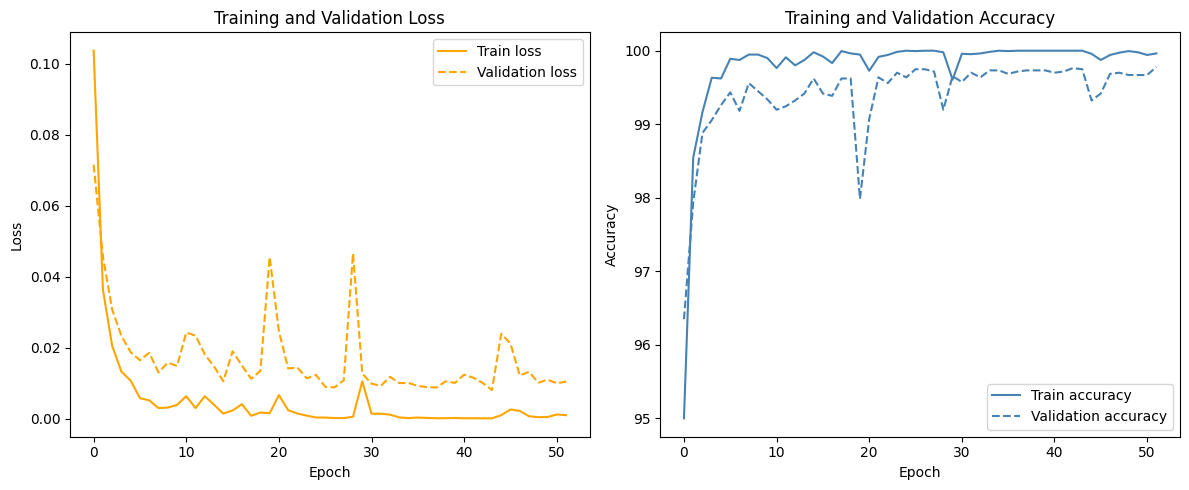

In [15]:
import matplotlib.pyplot as plt

# Plot training and validation loss
plt.figure(figsize=(12, 5))

# Loss plot
plt.subplot(1, 2, 1)
plt.plot(losses_train, color="orange", linestyle="-", label="Train loss")
plt.plot(losses_val, color="orange", linestyle="--", label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()

# Accuracy plot
plt.subplot(1, 2, 2)
plt.plot(accuracies_train, color="steelblue", linestyle="-", label="Train accuracy")
plt.plot(accuracies_val, color="steelblue", linestyle="--", label="Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

**Prepare Evaluation Dataset**

In [16]:


# Set the number of files to pick and the random seed
#random_seed = 42

# List all .pt files in the directory
if CURRENT_DATA == "itw":
    target_eval_files = eval_files
    target_eval_path = train_path
else:
    target_eval_path = DATASET_MAP[CURRENT_DATA]['eval']
    target_eval_files = [f for f in os.listdir(target_eval_path) if f.endswith('.pt')]

# Set the random seed for reproducibility
#random.seed(random_seed)

# Randomly select the specified number of files
# selected_files = random.sample(all_files, num_files_to_pick)

# Inspect a single .pt file before loading into classes
inspect_file = os.path.join(target_eval_path, target_eval_files[0])  # Select the first file from the random selection

# Inspect the data from the .pt file
inspect_data = torch.load(inspect_file)
print("Example of the .pt file",inspect_data[0])

# Initialize a list to store the features and labels
eval_features_list = []
eval_labels_list = []

# Load the features and labels for the selected .pt files
for file_name in target_eval_files:
    file_path = os.path.join(target_eval_path, file_name)
    eval_feature, eval_label = torch.load(file_path)
    eval_features_list.append(eval_feature)  # Append the tensors
    eval_labels_list.append(eval_label) # Append the labels

# Concatenate all the data into a single tensor
eval_features = torch.stack(eval_features_list)
print("Example of the features",eval_features[1])
eval_labels = torch.tensor(eval_labels_list)
print("Example of the labels",eval_labels)

# Debugging: Check the shapes of features and labels
print("Features shape:", eval_features.shape)
print("Labels shape:", eval_labels.shape)

# Create a TensorDataset and DataLoader
eval_dataset = TensorDataset(eval_features, eval_labels)
eval_dataLoader = DataLoader(eval_dataset, batch_size=64, shuffle=False)
print("The evaluation dataset has been successfully loaded into DataLoader.")


Example of the .pt file tensor([[-2.5297e+02, -2.6047e+02, -2.6629e+02,  ..., -2.6607e+02,
         -2.6822e+02, -2.7479e+02],
        [ 1.3263e+02,  1.4534e+02,  1.4754e+02,  ...,  1.4753e+02,
          1.4621e+02,  1.3949e+02],
        [ 4.5189e+01,  3.5358e+01,  3.6423e+01,  ...,  3.5895e+01,
          3.7915e+01,  3.5922e+01],
        ...,
        [ 5.8957e-01,  5.8957e-01,  5.8957e-01,  ..., -5.6364e-01,
         -5.6364e-01, -5.6364e-01],
        [ 4.4594e-01,  4.4594e-01,  4.4594e-01,  ..., -4.8912e-01,
         -4.8912e-01, -4.8912e-01],
        [-2.4152e-01, -2.4152e-01, -2.4152e-01,  ..., -1.1778e-01,
         -1.1778e-01, -1.1778e-01]])
Example of the features tensor([[-5.2117e+02, -5.1793e+02, -5.0403e+02,  ..., -2.6965e+02,
         -3.1034e+02, -3.0079e+02],
        [ 2.1901e-05,  3.3409e+00,  1.9050e+01,  ...,  2.2092e+02,
          1.8444e+02,  1.6087e+02],
        [-8.1068e-06,  1.3619e+00,  1.1314e+01,  ...,  4.7878e+01,
          6.3736e+01,  5.2497e+01],
        ...

In [19]:
import numpy as np
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = LCNN().to(device)

checkpoint = torch.load('lcnn_itw_checkpoint.pth', map_location=device, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])



<All keys matched successfully>


Evaluation Set:
Loss: 0.0106 | Accuracy: 99.62%
EER: 0.38% | Logit Threshold: 2.9019 | Prob Threshold: 0.9479
F1 Score: 0.9970
Precision: 0.9978
Recall: 0.9963
Predictions: [1]: 4012 | [0]: 2344


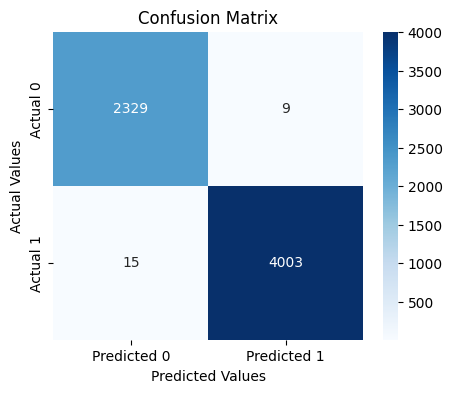

In [20]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns

def evaluate_on_eval_set(model, eval_dataLoader):
    model.eval()
    all_scores = []
    all_labels = []
    total = 0
    correct = 0
    total_loss = 0.0

    with torch.no_grad():
        for features, labels in eval_dataLoader:
            features, labels = features.to(device), labels.to(device)
            outputs = model(features)
            
            # Use labels.float().unsqueeze(1) to match BCEWithLogitsLoss expectations
            loss = criterion(outputs, labels.float().unsqueeze(1))
            total_loss += loss.item()

            all_scores.extend(outputs.cpu().numpy().flatten())
            all_labels.extend(labels.cpu().numpy().flatten())

    all_labels = np.array(all_labels)
    all_scores = np.array(all_scores)
    
    # 1. Calculate EER and the optimal Threshold first
    eer, threshold = calculate_eer(all_labels, all_scores)
    prob_threshold = expit(threshold)
    
    # 2. Use the EER threshold for ALL metrics to stay consistent
    preds = (all_scores >= threshold).astype(int)
    
    # 3. Calculate consistent metrics
    avg_loss = total_loss / len(eval_dataLoader)
    correct = (preds == all_labels).sum()
    accuracy = 100 * correct / len(all_labels)
    
    precision = precision_score(all_labels, preds)
    recall = recall_score(all_labels, preds)
    f1 = f1_score(all_labels, preds)

    # Print results with precision and recall
    print(f"\nEvaluation Set:")
    print(f"Loss: {avg_loss:.4f} | Accuracy: {accuracy:.2f}%")
    print(f"EER: {eer:.2f}% | Logit Threshold: {threshold:.4f} | Prob Threshold: {prob_threshold:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"Predictions: [1]: {np.count_nonzero(preds == 1)} | [0]: {np.count_nonzero(preds == 0)}")

    # Confusion Matrix
    cm = confusion_matrix(all_labels, preds)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Predicted 0', 'Predicted 1'],
                yticklabels=['Actual 0', 'Actual 1'])
    plt.xlabel('Predicted Values')
    plt.ylabel('Actual Values')
    plt.title('Confusion Matrix')
    plt.show()

evaluate_on_eval_set(model, eval_dataLoader)